## **Laporan Proyek Machine Learning - Prediksi Risiko Serangan Jantung**
**Metodologi:** CRISP-DM (*Cross-Industry Standard Process for Data Mining*)
* **Suci Oktavia Ramadhani** 2330511010
* **Salsabila Anggraina Putri** 2330511032
---

### **1. Project Overview**

Serangan jantung (*cardiovascular disease*) tetap menjadi salah satu penyebab utama mortalitas global dan nasional. Banyaknya faktor risiko yang bersifat multidimensi—mulai dari demografi (usia, gender), riwayat medis (hipertensi, diabetes), hingga gaya hidup (merokok, pola makan)—membuat proses diagnosis preventif menjadi kompleks.

Proyek ini bertujuan mengembangkan sistem prediksi cerdas berbasis *Machine Learning* menggunakan algoritma **Logistic Regression** dan algoritma **XGBoost Classifier** untuk mendeteksi dini apakah seorang pasien masuk ke dalam kategori berisiko tinggi terkena serangan jantung atau tidak dengan dataset dari **Kaggle**.

### **2. Business Understanding**

**Problem Statements**
1. Bagaimana karakteristik demografi (usia, gender) dan faktor medis mempengaruhi risiko serangan jantung seseorang?
2. Apakah algoritma *Advanced Ensemble Learning* (XGBoost) mampu memberikan performa prediksi risiko yang lebih baik dibandingkan model *Baseline* (Logistic Regression)?

**Goals**
1. Mengidentifikasi dan menganalisis korelasi faktor risiko terhadap indikasi serangan jantung.
2. Membangun model klasifikasi dengan tingkat pengenalan (*Recall* / sensitivitas) yang tinggi guna meminimalisir kesalahan diagnosis fatal (*False Negative*).

**Solution Statement**
* **Model Baseline:** *Logistic Regression* sebagai model statistik standar yang mudah diinterpretasikan.
* **Model Advanced:** *XGBoost Classifier* (Gradient Boosting) untuk mengoptimalkan akurasi dan menangani hubungan non-linear antar fitur.

### **3. Data Understanding**
Dataset yang digunakan berisi profil kesehatan masyarakat Indonesia terkait indikator medis dan serangan jantung.

**Variabel-Variabel pada Dataset:**
* `age`: Usia pasien (Numerik)
* `gender`: Jenis kelamin pasien (Kategorikal: Male, Female)
* `hypertension`: Riwayat tekanan darah tinggi (Biner: 0 = Tidak, 1 = Ya)
* `diabetes`: Riwayat penyakit gula (Biner: 0 = Tidak, 1 = Ya)
* `cholesterol_level`: Kadar kolesterol total (Numerik)
* `obesity`: Status obesitas (Biner: 0 = Tidak, 1 = Ya)
* `smoking_status`: Kebiasaan merokok (Kategorikal: Never, Past, Current)
* `dietary_habits`: Pola makan sehari-hari (Kategorikal: Healthy, Unhealthy)
* `stress_level`: Skala tingkat stres (Numerik/Ordinal: 1-10)
* `heart_attack`: Status terkena serangan jantung (**Target Biner**: 0 = Tidak, 1 = Ya)

In [ ]:
# =====================================================================
# LOAD DATA & DATA UNDERSTANDING
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca file dataset
from google.colab import drive
drive.mount('/content/drive/')
df = pd.read_csv('/content/drive/MyDrive/ML/heart_attack_prediction_indonesia.csv')

print("=== DIMENSI DATA ===")
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}\n")

print("=== INFORMASI DATASET ===")
df.info()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
=== DIMENSI DATA ===
Jumlah baris: 158355, Jumlah kolom: 28

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158355 entries, 0 to 158354
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             158355 non-null  int64  
 1   gender                          158355 non-null  object 
 2   region                          158355 non-null  object 
 3   income_level                    158355 non-null  object 
 4   hypertension                    158355 non-null  int64  
 5   diabetes                        158355 non-null  int64  
 6   cholesterol_level               158355 non-null  int64  
 7   obesity                         158355 non-null  int64  
 8   waist_circumference             158355 non-nul

In [ ]:
# =====================================================================
# LOAD DATA & DATA UNDERSTANDING
# =====================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca file dataset
from google.colab import drive
drive.mount('/content/drive/')
df = pd.read_csv('/content/drive/MyDrive/ML/heart_attack_prediction_indonesia.csv')

print("=== DIMENSI DATA ===")
print(f"Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}\n")

print("=== INFORMASI DATASET ===")
df.info()

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
=== DIMENSI DATA ===
Jumlah baris: 158355, Jumlah kolom: 28

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158355 entries, 0 to 158354
Data columns (total 28 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             158355 non-null  int64  
 1   gender                          158355 non-null  object 
 2   region                          158355 non-null  object 
 3   income_level                    158355 non-null  object 
 4   hypertension                    158355 non-null  int64  
 5   diabetes                        158355 non-null  int64  
 6   cholesterol_level               158355 non-null  int64  
 7   obesity                         158355 non-null  int64  
 8   waist_circumference             158355 non-nul

/tmp/ipykernel_3464/1936985819.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='heart_attack', data=df, palette='Set2')
/tmp/ipykernel_3464/1936985819.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='heart_attack', y='age', data=df, palette='Pastel1')


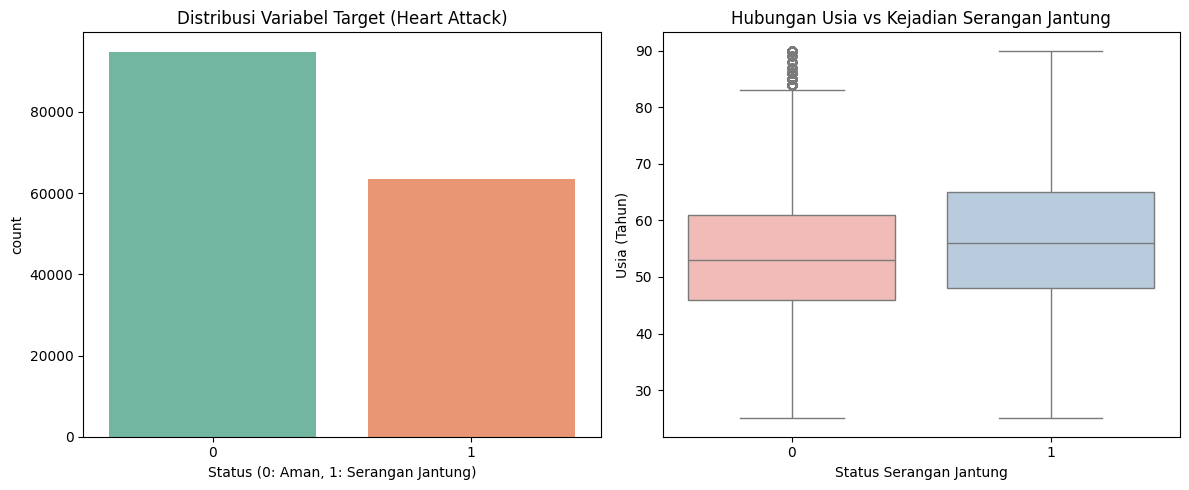

In [ ]:
# =====================================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# =====================================================================
# 1. Visualisasi Distribusi Target
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x='heart_attack', data=df, palette='Set2')
plt.title('Distribusi Variabel Target (Heart Attack)')
plt.xlabel('Status (0: Aman, 1: Serangan Jantung)')

# 2. Visualisasi Hubungan Usia dengan Serangan Jantung
plt.subplot(1, 2, 2)
sns.boxplot(x='heart_attack', y='age', data=df, palette='Pastel1')
plt.title('Hubungan Usia vs Kejadian Serangan Jantung')
plt.xlabel('Status Serangan Jantung')
plt.ylabel('Usia (Tahun)')

plt.tight_layout()
plt.show()

### **4. Data Preparation**
Pada tahap ini, data ditransformasikan agar siap dikonsumsi oleh algoritma:
1. **Label Encoding**: Mengubah kolom bertipe teks/kategorikal menjadi representasi angka numerik.
2. **Feature Selection**: Membatasi variabel input sesuai dengan fokus penelitian (Usia, Gender, Faktor Penyebab).
3. **Train-Test Split**: Membagi dataset menjadi data latih (80%) dan data uji (20%).
4. **Feature Scaling**: Menyamakan skala nilai fitur numerik menggunakan `StandardScaler`.

In [ ]:
# =====================================================================
# DATA PREPARATION EXECUTIONS
# =====================================================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_prepared = df.copy()

# 1. Proses Label Encoding otomatis untuk kolom teks
le = LabelEncoder()
for col in df_prepared.columns:
    if df_prepared[col].dtype == 'object':
        df_prepared[col] = le.fit_transform(df_prepared[col].astype(str))

# 2. Pemilihan Fitur Sesuai Masalah
fitur_pilihan = ['age', 'gender', 'hypertension', 'diabetes', 'cholesterol_level',
                 'obesity', 'smoking_status', 'dietary_habits', 'stress_level']

X = df_prepared[fitur_pilihan].fillna(0)
y = df_prepared['heart_attack']

# 3. Splitting Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Feature Scaling (Standarisasi)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Proses Data Preparation Selesai Sukses!")
print(f"X_train shape: {X_train_scaled.shape} | X_test shape: {X_test_scaled.shape}")

Proses Data Preparation Selesai Sukses!
X_train shape: (126684, 9) | X_test shape: (31671, 9)


### **5. Modeling**
Tahap ini melatih dua algoritma klasifikasi berbeda untuk dibandingkan efektivitasnya:

1. **Logistic Regression (Baseline Model)**
   Bekerja dengan memetakan fungsi linear ke dalam fungsi logistik (Sigmoid) yang menghasilkan nilai probabilitas antara 0 dan 1.
   $$\sigma(z) = \frac{1}{1 + e^{-z}}$$

2. **XGBoost Classifier (Advanced Model - Poin Plus)**
   Algoritma berbasis *Gradient Boosted Decision Trees* yang mengoptimalkan fungsi kerugian (*loss function*) menggunakan pendekatan ansambel sekuensial untuk mengoreksi eror dari pohon keputusan sebelumnya.

In [ ]:
# =====================================================================
# MODELING TRAINING
# =====================================================================
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Inisialisasi model
model_lr = LogisticRegression(random_state=42)
model_xgb = XGBClassifier(random_state=42, eval_metric='logloss')

# Proses Fitting / Pelatihan Data
model_lr.fit(X_train_scaled, y_train)
model_xgb.fit(X_train_scaled, y_train)

print("Model Logistic Regression dan XGBoost Classifier berhasil dilatih!")

Model Logistic Regression dan XGBoost Classifier berhasil dilatih!


### **6. Evaluation**
Evaluasi performa model dilakukan menggunakan metrik matriks kontingensi (*Confusion Matrix*), *Accuracy*, *Precision*, dan *Recall*. Dalam domain medis, nilai **Recall** menjadi acuan utama demi meminimalisir persentase penderita sakit yang terprediksi sehat.

=================== REPORT LOGISTIC REGRESSION ===================
              precision    recall  f1-score   support

           0       0.71      0.82      0.76     18971
           1       0.65      0.51      0.57     12700

    accuracy                           0.70     31671
   macro avg       0.68      0.67      0.67     31671
weighted avg       0.69      0.70      0.69     31671


==================== REPORT XGBOOST CLASSIFIER ===================
              precision    recall  f1-score   support

           0       0.72      0.80      0.76     18971
           1       0.65      0.54      0.59     12700

    accuracy                           0.70     31671
   macro avg       0.69      0.67      0.68     31671
weighted avg       0.69      0.70      0.69     31671



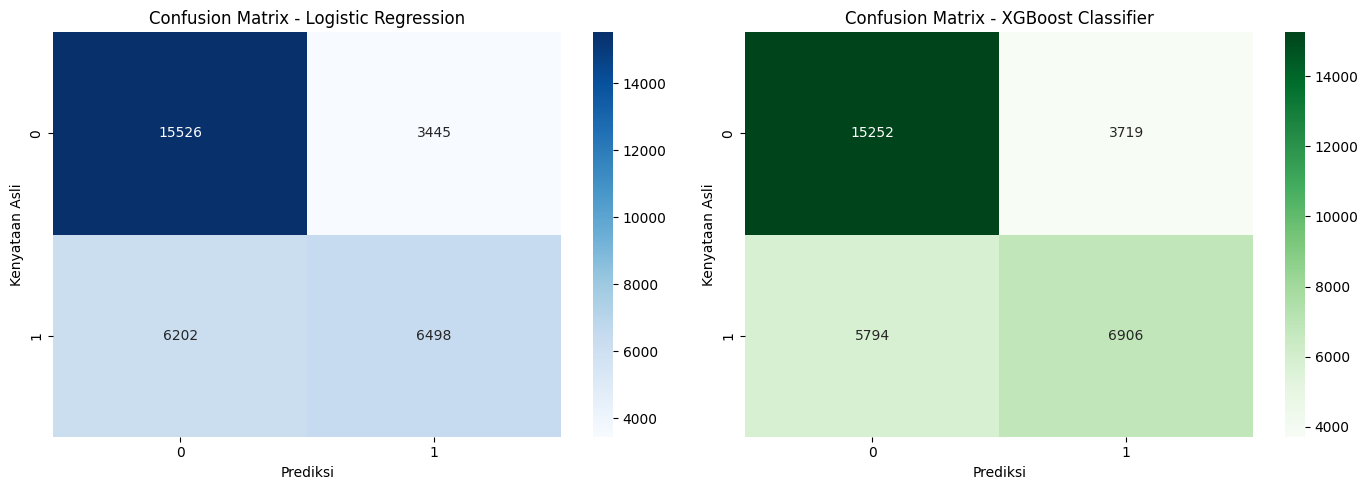

In [ ]:
# =====================================================================
# EVALUATION & CONFUSION MATRIX VISUALIZATION
# =====================================================================
from sklearn.metrics import classification_report, confusion_matrix

# Prediksi data uji
y_pred_lr = model_lr.predict(X_test_scaled)
y_pred_xgb = model_xgb.predict(X_test_scaled)

print("=================== REPORT LOGISTIC REGRESSION ===================")
print(classification_report(y_test, y_pred_lr))

print("\n==================== REPORT XGBOOST CLASSIFIER ===================")
print(classification_report(y_test, y_pred_xgb))

# Visualisasi Heatmap Confusion Matrix Berdampingan
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix - Logistic Regression')
ax[0].set_xlabel('Prediksi')
ax[0].set_ylabel('Kenyataan Asli')

sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title('Confusion Matrix - XGBoost Classifier')
ax[1].set_xlabel('Prediksi')
ax[1].set_ylabel('Kenyataan Asli')

plt.tight_layout()
plt.show()

### **MENYIMPAN MODEL**

In [ ]:
import joblib
#Pustaka khusus untuk otomatis mendownload berkas
from google.colab import files

# 1. Menyimpan Model XGBoost menjadi file .pkl
joblib.dump(model_xgb, 'model_SerJan_xgb.pkl')

# 2. Menyimpan Scaler menjadi file .pkl
joblib.dump(scaler, 'scaler.pkl')

print("Berhasil membuat file .pkl!")

# 3. Otomatis mengunduh kedua file tersebut ke laptop/komputer kamu
print("Memulai pengunduhan file ke komputer...")
files.download('model_SerJan_xgb.pkl')
files.download('scaler.pkl')

Berhasil membuat file .pkl!
Memulai pengunduhan file ke komputer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### **7. Deployment (Aplikasi Prediksi Interaktif)**
Mengimplementasikan model terbaik (*XGBoost*) ke dalam bentuk antarmuka pengguna interaktif (*Web Widget*) langsung di dalam lingkungan Google Colab menggunakan pustaka `ipywidgets`.

In [ ]:
# =====================================================================
# DEPLOYMENT INTERACTIVE APP WIDGET
# =====================================================================
import ipywidgets as widgets
from IPython.display import display, clear_output

def fungsi_prediksi_inti(age, gender, hypertension, diabetes, cholesterol, obesity, smoking, diet, stress):
    input_data = np.array([[age, gender, hypertension, diabetes, cholesterol, obesity, smoking, diet, stress]])
    input_data_scaled = scaler.transform(input_data)

    hasil = model_xgb.predict(input_data_scaled)
    prob = model_xgb.predict_proba(input_data_scaled)[0][1]

    print("\n" + "="*45)
    print("         SISTEM DETEKSI SERANGAN JANTUNG        ")
    print("="*45)
    if hasil[0] == 1:
        print(f"DIAGNOSIS    : BERISIKO TINGGI SERANGAN JANTUNG")
        print(f"PROBABILITAS : {prob * 100:.2f}%")
    else:
        print(f"DIAGNOSIS    : TINGKAT RISIKO RENDAH / AMAN")
        print(f"PROBABILITAS : {prob * 100:.2f}%")
    print("="*45)

# Pembuatan Form Pengguna
w_age = widgets.IntSlider(value=45, min=1, max=100, description='Usia:')
w_gender = widgets.Dropdown(options=[('Perempuan', 0), ('Laki-laki', 1)], value=1, description='Gender:')
w_hyper = widgets.Dropdown(options=[('Tidak', 0), ('Ya', 1)], value=0, description='Hipertensi:')
w_diabetes = widgets.Dropdown(options=[('Tidak', 0), ('Ya', 1)], value=0, description='Diabetes:')
w_chol = widgets.IntSlider(value=210, min=100, max=400, description='Kolesterol:')
w_obesity = widgets.Dropdown(options=[('Tidak', 0), ('Ya', 1)], value=0, description='Obesitas:')
w_smoking = widgets.Dropdown(options=[('Tidak Pernah', 1), ('Mantan Perokok', 2), ('Perokok Aktif', 0)], value=1, description='Status Merokok:')
w_diet = widgets.Dropdown(options=[('Sehat', 0), ('Tidak Sehat', 1)], value=0, description='Pola Diet:')
w_stress = widgets.IntSlider(value=5, min=1, max=10, description='Skala Stres:')

btn = widgets.Button(description="Analisis Risiko Sekarang", button_style='danger')
out = widgets.Output()

def on_click_callback(b):
    with out:
        clear_output()
        fungsi_prediksi_inti(w_age.value, w_gender.value, w_hyper.value, w_diabetes.value,
                             w_chol.value, w_obesity.value, w_smoking.value, w_diet.value, w_stress.value)

btn.on_click(on_click_callback)

print("Isi parameter kesehatan di bawah untuk memprediksi:")
layout_tampilan = widgets.VBox([w_age, w_gender, w_hyper, w_diabetes, w_chol, w_obesity, w_smoking, w_diet, w_stress, btn, out])
display(layout_tampilan)

Isi parameter kesehatan di bawah untuk memprediksi:
